# Requirement 1 — Single Campaign, Stochastic Environment

A learner repeatedly bids in a first-price auction for a single advertising campaign. At each round $t$ the learner picks a bid $b$ from a discrete grid, wins if $b \geq m_t$ (the highest competing bid drawn i.i.d. from Beta$(k,1)$), and pays $b$ when it wins. The goal is to maximise cumulative utility $\sum_t (v - b_t)\mathbf{1}[\text{win}]$ subject to the total budget constraint $\sum_t b_t \mathbf{1}[\text{win}] \leq B$.

**Two agents are compared:**
- **UCB1** — budget-unaware; treats each bid level as an independent MAB arm.
- **UCB-like** — budget-aware; maintains optimistic reward estimates and empirical cost estimates, then solves an LP at each round to find the budget-feasible randomised bid that maximises optimistic utility.

**Two budget scenarios** isolate the role of the constraint:

| Scenario | $B$ | $\rho = B/T$ | Effect |
|----------|-----|--------------|--------|
| Generous | 1600 | 0.16 | Non-binding; optimal bid cost $\approx 0.13 < \rho$, both agents converge |
| Tight | 400 | 0.04 | Binding; UCB1 overspends, UCB-like respects budget via LP |

**Clairvoyant benchmark:** LP optimum on the true win probabilities with cost constraint $\rho = B/T$.

In [1]:
import sys
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR   = ROOT / "data" / "picklefiles"
OUTPUTS_DIR = ROOT / "outputs"

def load_pickle(name):
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the experiment cell first.")
    with path.open("rb") as f:
        return pickle.load(f)

def show_png(relative_path, width=900):
    path = OUTPUTS_DIR / relative_path
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"*Missing plot:* `{path}` — run the experiment cell first."))

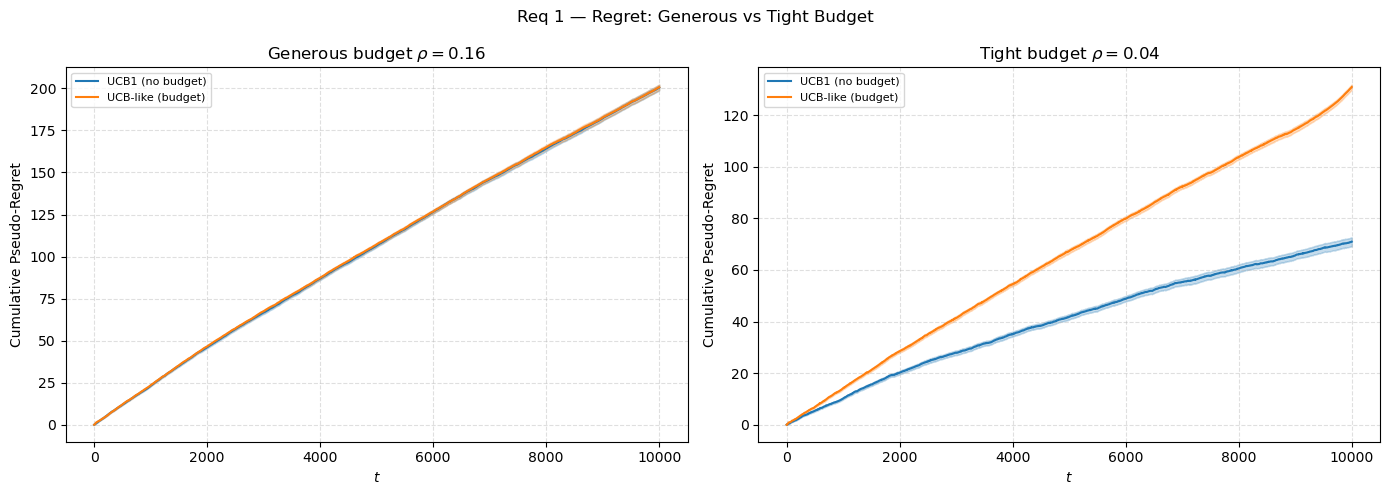

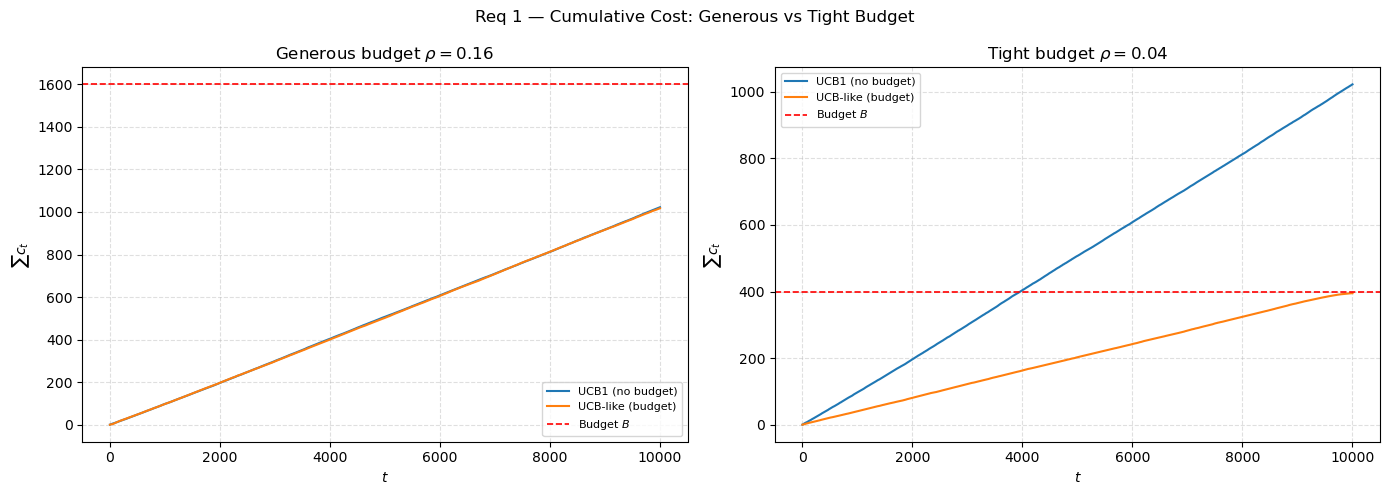

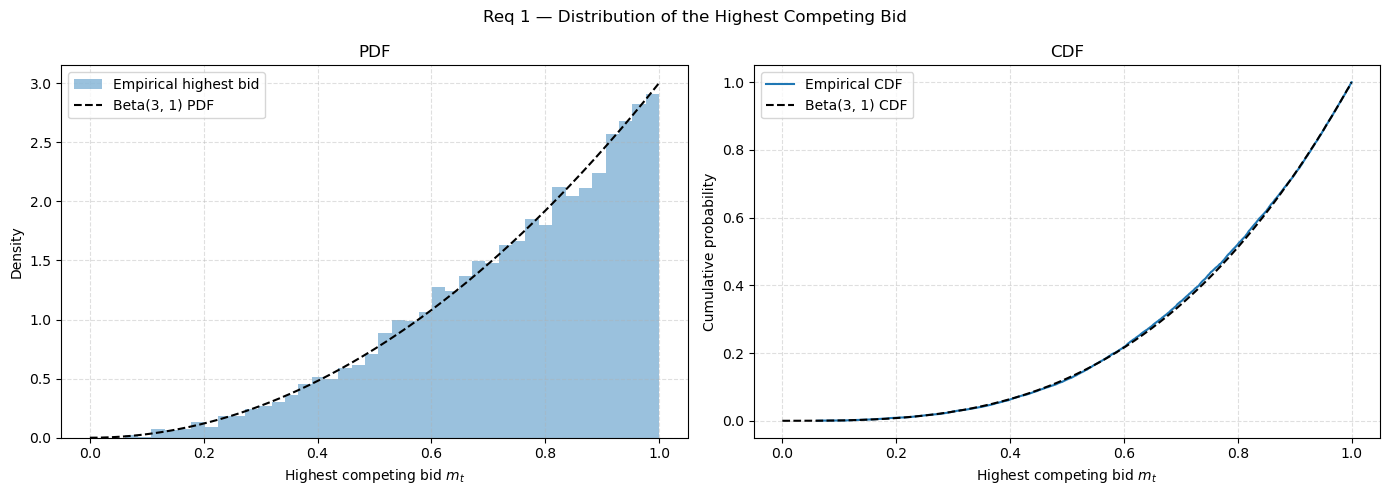

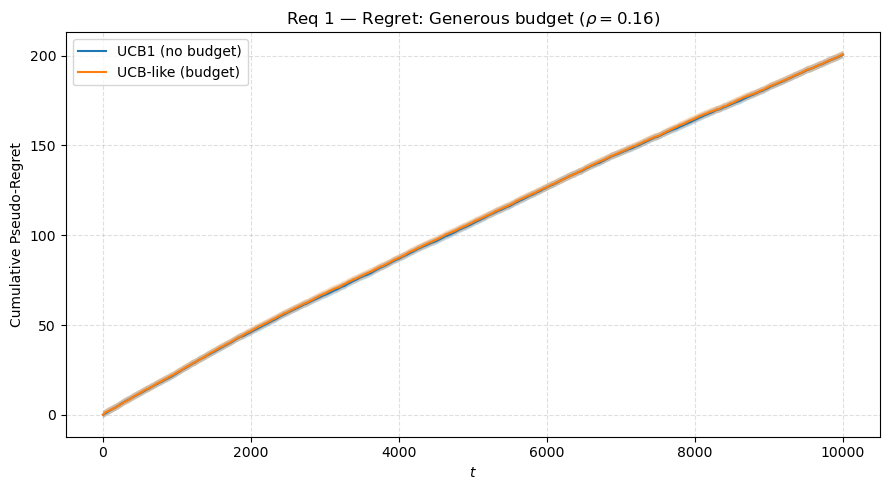

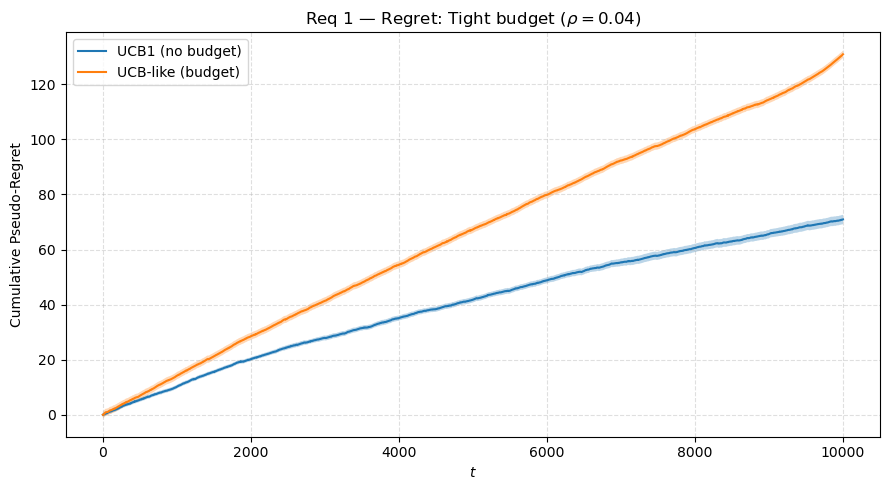

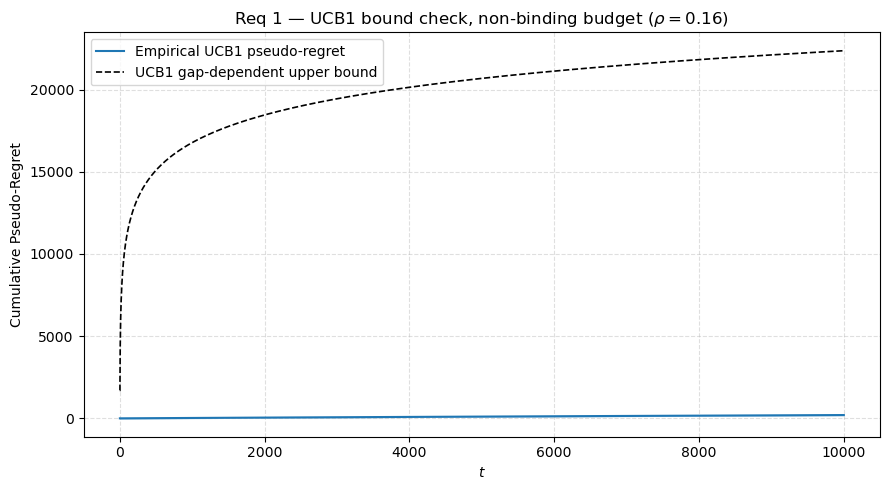

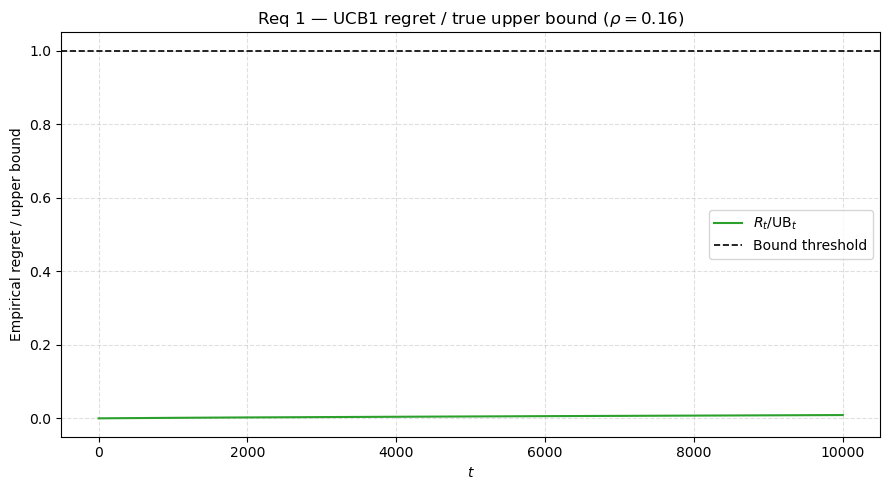

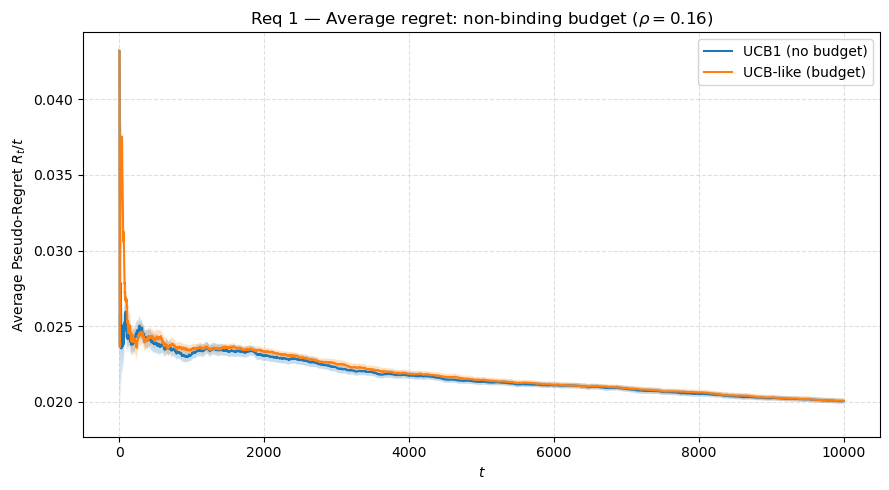

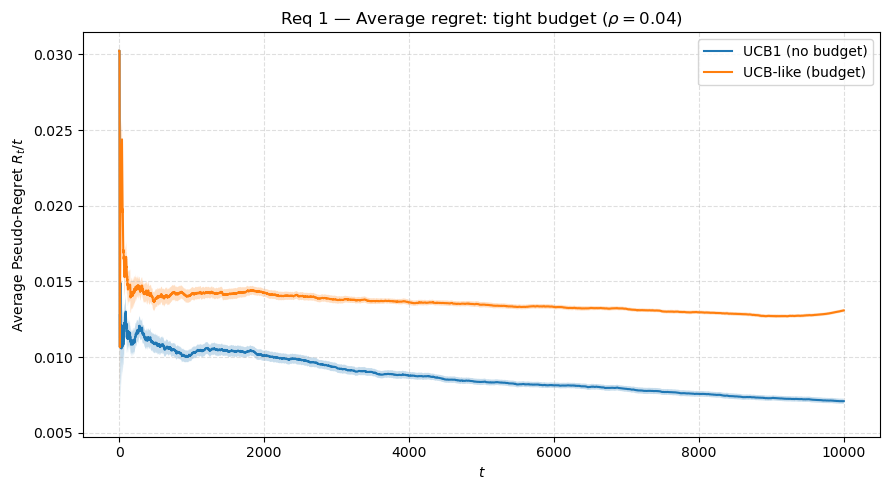

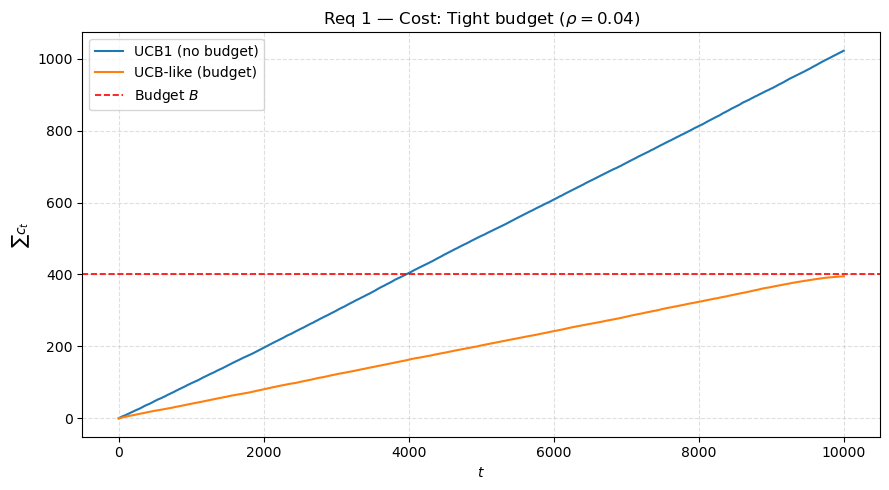

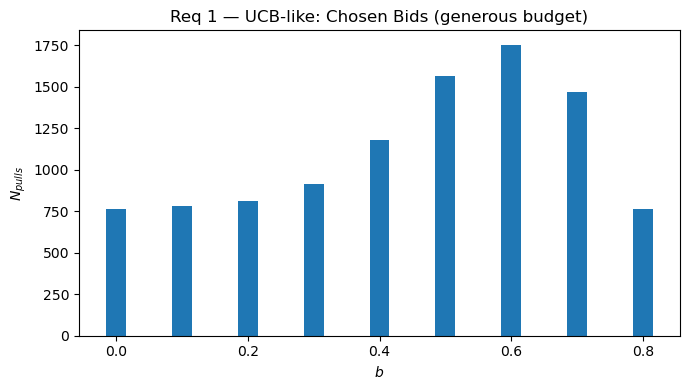

In [2]:
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(message)s")

from utils.run_req1 import run_req1
run_req1()

## Parameters

The implementation lives in `utils/run_req1.py`. The environment is `SingleCampaignEnv` (first-price auction, competing bids Beta$(k,1)$); the learners are `UCB1BiddingAgent` and `UCBLikeBiddingAgent`.

In [3]:
from utils.run_req1 import VALUE, T, N_TRIALS, N_COMPETITORS, AVAILABLE_BIDS, BUDGET_GENEROUS, BUDGET_TIGHT

print(f"Value v          = {VALUE}")
print(f"Horizon T        = {T}")
print(f"Trials           = {N_TRIALS}")
print(f"Competitors k    = {N_COMPETITORS}")
print(f"Bid grid         = {np.array2string(AVAILABLE_BIDS, precision=2)}")
print(f"Generous budget  = {BUDGET_GENEROUS}  (ρ = {BUDGET_GENEROUS/T:.4f})")
print(f"Tight budget     = {BUDGET_TIGHT}   (ρ = {BUDGET_TIGHT/T:.4f})")

## Clairvoyant Benchmark

The clairvoyant LP maximises expected utility subject to the per-round budget rate $\rho = B/T$. For bid $b$ with win probability $p(b) = \Pr(b \geq m)$, expected utility is $(v - b)\,p(b)$ and expected cost is $b\,p(b)$. The LP finds the optimal randomised bid $\gamma \in \Delta_K$ satisfying $\sum_k \gamma_k b_k p(b_k) \leq \rho$.

In [4]:
from utils.environments import SingleCampaignEnv
from utils.experiments import compute_clairvoyant_single

rows = []
for scenario, budget in [("Generous", BUDGET_GENEROUS), ("Tight", BUDGET_TIGHT)]:
    env = SingleCampaignEnv(value=VALUE, budget=budget, T=T,
                            available_bids=AVAILABLE_BIDS, n_competitors=N_COMPETITORS, seed=0)
    gamma, opt_utility, exp_payment = compute_clairvoyant_single(
        env.available_bids, VALUE, budget / T, env.win_probabilities()
    )
    active = [(f"{b:.2f}", f"{p:.4f}") for b, p in zip(env.available_bids, gamma) if p > 1e-6]
    rows.append(f"| {scenario} | {budget:.0f} | {budget/T:.4f} | {opt_utility:.5f} | {exp_payment:.5f} | {active} |")

header = "| Scenario | B | ρ | Opt utility/round | Exp cost/round | Active bid mix (bid, probability) |"
sep    = "| --- | --- | --- | --- | --- | --- |"
display(Markdown("\n".join([header, sep] + rows)))

## Results Summary

Final cumulative pseudo-regret and budget utilisation for each agent/scenario pair, averaged over all trials.

In [5]:
try:
    results = {
        "Generous / UCB1":     (BUDGET_GENEROUS, load_pickle("req1_ucb1_generous_results.pkl")),
        "Generous / UCB-like": (BUDGET_GENEROUS, load_pickle("req1_ucblike_generous_results.pkl")),
        "Tight / UCB1":        (BUDGET_TIGHT,    load_pickle("req1_ucb1_tight_results.pkl")),
        "Tight / UCB-like":    (BUDGET_TIGHT,    load_pickle("req1_ucblike_tight_results.pkl")),
    }
except FileNotFoundError as _e:
    display(Markdown(f"**Run the `run_req1()` cell above first, then re-run this cell.**\n\n`{_e}`"))
    raise

rows = []
for label, (budget, res) in results.items():
    T_run = len(res["mean_regret"])
    rows.append(
        f"| {label} | {res['n_trials']} | {res['mean_regret'][-1]:.2f} | "
        f"{res['mean_regret'][-1]/T_run:.5f} | {res['mean_cumcost'][-1]:.2f} | "
        f"{budget - res['mean_cumcost'][-1]:.2f} |"
    )

header = "| Case | Trials | Final regret | Avg regret | Final cost | Budget slack |"
sep    = "| --- | --- | --- | --- | --- | --- |"
display(Markdown("\n".join([header, sep] + rows)))